In [1]:
import numpy as np
# rng = np.random.default_rng(2020)

# Solve the n-Queen problem with Simulated Annealing.
#### What will be tested:
* That you understand every line of your code, not just copy from somewhere
* That your program compiles correctly
* Correctness of the program logic
* That the result is obtained in a reasonable time
#### What you need to do:
* Complete the `value` function
* Implement two search operators in `swap` and `permutation`
* Implement the replacement in `simulated_annealing`
#### DDL: 3.25

In [2]:
class NQueenProblem:
    def __init__(self, grid, n, method) -> None:
        # grid is a 1D array, each element represents the position of a queen
        # In init state of the n-queen problem, if n = 8, grid = [0, 1, 2, 3, 4, 5, 6, 7]
        # represents the following state:
        # 1 0 0 0 0 0 0 0
        # 0 1 0 0 0 0 0 0
        # 0 0 1 0 0 0 0 0
        # 0 0 0 1 0 0 0 0
        # 0 0 0 0 1 0 0 0
        # 0 0 0 0 0 1 0 0
        # 0 0 0 0 0 0 1 0
        # 0 0 0 0 0 0 0 1
        # all queens in the initial state have conflicts with each other
        self.grid = grid
        self.n = n
        self.method = method

    def value(self):  # 冲突对数
        # TODO: evaluate the current state, return a scalar value
        # the evaluation function calculates the number of attacking pairs of queens on the board
        # return the number of conflicts
        conflicts = 0
        for i in range(self.n-1):
            for j in range(i + 1, self.n):
                if abs(self.grid[i] - self.grid[j]) == abs(i - j):  # 对角线。行、列由定义自动满足
                    conflicts += 1
        return conflicts    

    def local_search(self):
        # using the method to generate a new grid
        new_grid = self.method(self.grid, self.n)
        return NQueenProblem(new_grid, self.n, self.method)

    def print_grid(self):
        matrix = np.zeros((self.n, self.n))
        for i in range(self.n):
            matrix[self.grid[i], i] = 1
        for i in range(self.n):
            for j in range(self.n):
                print(int(matrix[i, j]), end=' ')
            print()


#### Check the correctness of the value function:

In [3]:
grid = np.array([7,4,6,1,5,3,2,0])
problem = NQueenProblem(grid, 8, None)
problem.print_grid()
problem.value()

0 0 0 0 0 0 0 1 
0 0 0 1 0 0 0 0 
0 0 0 0 0 0 1 0 
0 0 0 0 0 1 0 0 
0 1 0 0 0 0 0 0 
0 0 0 0 1 0 0 0 
0 0 1 0 0 0 0 0 
1 0 0 0 0 0 0 0 


0 0 0 0 0 0 0 1 
0 0 0 1 0 0 0 0 
0 0 0 0 0 0 1 0 
0 0 0 0 0 1 0 0 
0 1 0 0 0 0 0 0 
0 0 0 0 1 0 0 0 
0 0 1 0 0 0 0 0 
1 0 0 0 0 0 0 0 


5

In [16]:
def order_crossover(parent1, parent2, n): #杂交

    idx1, idx2 = sorted(np.random.choice(range(n), 2, replace=False)) # 选择杂交中交换的区间
    
    child = np.full(n, -1) #初始化后代
    subset = parent1[idx1:idx2+1]
    child[idx1:idx2+1] = subset #将parent1的子序列复制到child中
    
    fill_values = [x for x in parent2 if x not in subset] #从parent2中选择不在子序列中的元素，按照顺序填充到child中
    
    current_fill = 0 
    for i in range(n):
        if child[i] == -1:
            child[i] = fill_values[current_fill]
            current_fill += 1
            
    return child

def swap_mutation(grid, n):  #变异
    i, j = np.random.choice(n, 2, replace=False)
    grid[i], grid[j] = grid[j], grid[i]
    return grid

def genetic_algorithm(n, pop_size=100, max_generations=1000, mutation_rate=0.1):
    # 以随机排列的形式初始化种群，每个个体都是一个长度为n的数组，表示每列皇后的位置
    population = [np.random.permutation(n) for _ in range(pop_size)] 
    history = []
    best_solution = None
    min_conflicts = float('inf') #最小冲突初始化为无穷大

    prob = NQueenProblem(None, n, None) #初始化一次问题实例，方便后面用他的value函数计算冲突数

    for generation in range(max_generations):  #迭代次数      
        scores = []
        for individual in population:
            prob.grid = individual #将个体编码传进实例参数，以正确计算value
            conflicts = prob.value()
            scores.append(conflicts)
        
        scores = np.array(scores)
        
        # Track best solution
        current_best_idx = np.argmin(scores)  #找出冲突最少的个体
        current_best_conflicts = scores[current_best_idx]
        history.append(current_best_conflicts)
        
        if current_best_conflicts < min_conflicts:  
            min_conflicts = current_best_conflicts
            best_solution = population[current_best_idx]
        
        if min_conflicts == 0: #找到完美解，提前终止
            print(f"Solution found at generation {generation}!")
            break
            
        # Selection & Reproduction
        new_population = []
        
        new_population.append(population[current_best_idx]) #先加入当前最优个体 
        
        # 当个体数量不够时，利用锦标赛法繁殖新个体进行补充
        while len(new_population) < pop_size:
            # 锦标赛挑选法
            # Select 2 parents
            # Parent 1
            # 种群中选5个候选者，其中适应度最好的那个被选为parent1
            candidates = np.random.choice(len(population), 5, replace=False)
            p1_idx = candidates[np.argmin(scores[candidates])]
            parent1 = population[p1_idx]
            
            # Parent 2
            candidates = np.random.choice(len(population), 5, replace=False)
            p2_idx = candidates[np.argmin(scores[candidates])]
            parent2 = population[p2_idx]
            
            # Crossover
            child = order_crossover(parent1, parent2, n)
            
            # Mutation
            if np.random.rand() < mutation_rate:
                child = swap_mutation(child, n)
                
            new_population.append(child)
            
        population = new_population

    return NQueenProblem(best_solution, n, None), history

Solution found at generation 62!
Final Solution Grid:
0 0 0 0 0 0 0 0 1 0 0 0 
0 0 0 0 0 1 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 1 0 0 
0 0 0 0 0 0 1 0 0 0 0 0 
0 1 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 1 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 1 
1 0 0 0 0 0 0 0 0 0 0 0 
0 0 1 0 0 0 0 0 0 0 0 0 
0 0 0 0 1 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 1 0 
0 0 0 1 0 0 0 0 0 0 0 0 
Final Conflicts: 0


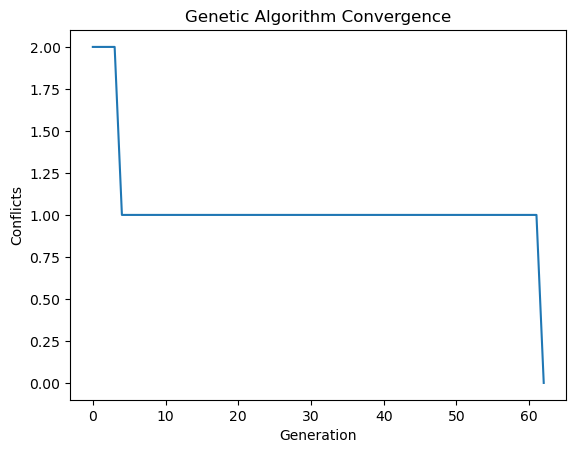

In [19]:
# Run the Genetic Algorithm
import matplotlib.pyplot as plt
n_queens = 12
solution_ga, record_ga = genetic_algorithm(n_queens, pop_size=100, max_generations=200, mutation_rate=0.2)

print("Final Solution Grid:")
solution_ga.print_grid()
print("Final Conflicts:", solution_ga.value())

# Plot the convergence
plt.plot(record_ga)
plt.title('Genetic Algorithm Convergence')
plt.xlabel('Generation')
plt.ylabel('Conflicts')
plt.show()